In [ ]:
import requests
import pandas as pd
import numpy as np

In [ ]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(url)

data = response.json()

print(response.status_code)

200


In [ ]:
df = pd.DataFrame(data["items"])

df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76041,2858,197043,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34249,2381,164116,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21943,11,89412,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15267,53,82480,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15613,24,74045,master,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [ ]:
df = df[[
    "name",
    "owner",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at",
    "updated_at",
    "license"
]]

df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197043,76041,197043,2858,2015-11-07T01:19:20Z,2026-08-15T20:13:15Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164116,34249,164116,2381,2018-10-29T13:56:00Z,2026-08-15T20:00:34Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89412,21943,89412,11,2021-03-03T01:34:05Z,2026-08-15T19:23:28Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82480,15267,82480,53,2018-08-21T11:20:39Z,2026-08-15T17:41:42Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74045,15613,74045,24,2014-07-15T19:11:19Z,2026-08-15T20:01:06Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [ ]:
df["owner"] = df["owner"].apply(
    lambda x: x["login"] if isinstance(x, dict) else None
)

df["license"] = df["license"].apply(
    lambda x: x["name"] if isinstance(x, dict) else None
)

df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197043,76041,197043,2858,2015-11-07T01:19:20Z,2026-08-15T20:13:15Z,Apache License 2.0
1,transformers,huggingface,Python,164116,34249,164116,2381,2018-10-29T13:56:00Z,2026-08-15T20:00:34Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89412,21943,89412,11,2021-03-03T01:34:05Z,2026-08-15T19:23:28Z,MIT License
3,funNLP,fighting41love,Python,82480,15267,82480,53,2018-08-21T11:20:39Z,2026-08-15T17:41:42Z,None
4,awesome-machine-learning,josephmisiti,Python,74045,15613,74045,24,2014-07-15T19:11:19Z,2026-08-15T20:01:06Z,Other


In [ ]:
df.isnull().sum()

,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,22


In [ ]:
df["language"] = df["language"].fillna("Unknown")
df["license"] = df["license"].fillna("No License")

In [ ]:
df.isnull().sum()

,0
name,0
owner,0
language,0
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [ ]:
df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
})

In [ ]:
df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197043,76041,197043,2858,2015-11-07 01:19:20+00:00,2026-08-15 20:13:15+00:00,Apache License 2.0
1,transformers,huggingface,Python,164116,34249,164116,2381,2018-10-29 13:56:00+00:00,2026-08-15 20:00:34+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89412,21943,89412,11,2021-03-03 01:34:05+00:00,2026-08-15 19:23:28+00:00,MIT License
3,funNLP,fighting41love,Python,82480,15267,82480,53,2018-08-21 11:20:39+00:00,2026-08-15 17:41:42+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74045,15613,74045,24,2014-07-15 19:11:19+00:00,2026-08-15 20:01:06+00:00,Other


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   name          100 non-null    object             
 1   owner         100 non-null    object             
 2   language      100 non-null    object             
 3   stars         100 non-null    int64              
 4   forks         100 non-null    int64              
 5   watchers      100 non-null    int64              
 6   open_issues   100 non-null    int64              
 7   created_date  100 non-null    datetime64[ns, UTC]
 8   updated_date  100 non-null    datetime64[ns, UTC]
 9   license       100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(4), object(4)
memory usage: 7.9+ KB


In [ ]:
df.to_csv("github_projects.csv", index=False)

In [ ]:
df_check = pd.read_csv("github_projects.csv")

df_check.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197043,76041,197043,2858,2015-11-07 01:19:20+00:00,2026-08-15 20:13:15+00:00,Apache License 2.0
1,transformers,huggingface,Python,164116,34249,164116,2381,2018-10-29 13:56:00+00:00,2026-08-15 20:00:34+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89412,21943,89412,11,2021-03-03 01:34:05+00:00,2026-08-15 19:23:28+00:00,MIT License
3,funNLP,fighting41love,Python,82480,15267,82480,53,2018-08-21 11:20:39+00:00,2026-08-15 17:41:42+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74045,15613,74045,24,2014-07-15 19:11:19+00:00,2026-08-15 20:01:06+00:00,Other


In [ ]:
df_check.shape

(100, 10)

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("github_projects.csv")

In [ ]:
conn = sqlite3.connect("github_projects.db")

In [ ]:
df.to_sql("Repositories", conn, if_exists="replace", index=False)

100

In [ ]:
pd.read_sql_query("SELECT * FROM Repositories LIMIT 5;", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197043,76041,197043,2858,2015-11-07 01:19:20+00:00,2026-08-15 20:13:15+00:00,Apache License 2.0
1,transformers,huggingface,Python,164116,34249,164116,2381,2018-10-29 13:56:00+00:00,2026-08-15 20:00:34+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89412,21943,89412,11,2021-03-03 01:34:05+00:00,2026-08-15 19:23:28+00:00,MIT License
3,funNLP,fighting41love,Python,82480,15267,82480,53,2018-08-21 11:20:39+00:00,2026-08-15 17:41:42+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74045,15613,74045,24,2014-07-15 19:11:19+00:00,2026-08-15 20:01:06+00:00,Other


In [ ]:
pd.read_sql_query("""
SELECT *
FROM Repositories
WHERE stars > 10000;
""", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197043,76041,197043,2858,2015-11-07 01:19:20+00:00,2026-08-15 20:13:15+00:00,Apache License 2.0
1,transformers,huggingface,Python,164116,34249,164116,2381,2018-10-29 13:56:00+00:00,2026-08-15 20:00:34+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89412,21943,89412,11,2021-03-03 01:34:05+00:00,2026-08-15 19:23:28+00:00,MIT License
3,funNLP,fighting41love,Python,82480,15267,82480,53,2018-08-21 11:20:39+00:00,2026-08-15 17:41:42+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74045,15613,74045,24,2014-07-15 19:11:19+00:00,2026-08-15 20:01:06+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
65,machine-learning-systems-design,chiphuyen,HTML,10516,1628,10516,11,2019-11-24 23:16:28+00:00,2026-08-15 19:17:32+00:00,No License
66,Machine-Learning,Jack-Cherish,Python,10369,5065,10369,7,2017-03-25 07:32:37+00:00,2026-08-15 07:37:42+00:00,No License
67,machine-learning-notes,roboticcam,Jupyter Notebook,10326,1825,10326,28,2018-02-15 15:42:33+00:00,2026-08-15 10:56:27+00:00,No License
68,3D-Machine-Learning,timzhang642,Unknown,10193,1797,10193,21,2017-08-12 15:20:54+00:00,2026-08-14 21:19:04+00:00,No License


In [ ]:
pd.read_sql_query("""
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%';
""", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,awesome-machine-learning,josephmisiti,Python,74045,15613,74045,24,2014-07-15 19:11:19+00:00,2026-08-15 20:01:06+00:00,Other
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36283,7434,36283,67,2021-01-02 12:08:37+00:00,2026-08-15 18:51:13+00:00,No License
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28860,6149,28860,32,2016-10-09 21:20:25+00:00,2026-08-15 19:57:02+00:00,Creative Commons Attribution Share Alike 4.0 I...
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24756,4195,24756,31,2018-11-01 04:34:19+00:00,2026-08-15 19:56:02+00:00,MIT License
4,awesome-production-machine-learning,EthicalML,Unknown,20847,2590,20847,32,2018-08-15 14:28:41+00:00,2026-08-15 20:01:15+00:00,MIT License
5,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20458,5521,20458,1,2018-05-09 12:33:08+00:00,2026-08-15 19:17:38+00:00,MIT License
6,stanford-cs-229-machine-learning,afshinea,Unknown,20106,4248,20106,20,2018-08-04 23:01:00+00:00,2026-08-15 18:37:57+00:00,MIT License
7,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18102,3970,18102,47,2015-09-12 14:51:38+00:00,2026-08-15 18:38:43+00:00,Creative Commons Zero v1.0 Universal
8,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13915,3092,13915,3,2020-04-17 04:29:23+00:00,2026-08-15 11:04:55+00:00,No License
9,machine-learning-interview,khangich,Unknown,12783,2042,12783,9,2020-08-11 06:26:32+00:00,2026-08-15 19:57:03+00:00,No License


In [ ]:
pd.read_sql_query("""
SELECT *
FROM Repositories
WHERE stars > 1000 AND forks > 100;
""", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197043,76041,197043,2858,2015-11-07 01:19:20+00:00,2026-08-15 20:13:15+00:00,Apache License 2.0
1,transformers,huggingface,Python,164116,34249,164116,2381,2018-10-29 13:56:00+00:00,2026-08-15 20:00:34+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89412,21943,89412,11,2021-03-03 01:34:05+00:00,2026-08-15 19:23:28+00:00,MIT License
3,funNLP,fighting41love,Python,82480,15267,82480,53,2018-08-21 11:20:39+00:00,2026-08-15 17:41:42+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74045,15613,74045,24,2014-07-15 19:11:19+00:00,2026-08-15 20:01:06+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
95,Machine-learning-learning-notes,Vay-keen,Unknown,7763,1879,7763,28,2018-03-24 06:48:10+00:00,2026-08-14 17:10:02+00:00,No License
96,awesome-youtubers,JoseDeFreitas,Markdown,7682,493,7682,2,2020-08-25 14:18:15+00:00,2026-08-15 16:19:26+00:00,Creative Commons Zero v1.0 Universal
97,Learn_Machine_Learning_in_3_Months,llSourcell,Unknown,7607,2311,7607,19,2018-03-02 10:59:53+00:00,2026-08-14 15:37:04+00:00,No License
98,h2o-3,h2oai,Jupyter Notebook,7503,2027,7503,2880,2014-03-03 16:08:07+00:00,2026-08-15 07:17:42+00:00,Apache License 2.0


In [ ]:
pd.read_sql_query("""
SELECT *
FROM Repositories
WHERE language = 'Python' OR language = 'Jupyter Notebook';
""", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,transformers,huggingface,Python,164116,34249,164116,2381,2018-10-29 13:56:00+00:00,2026-08-15 20:00:34+00:00,Apache License 2.0
1,ML-For-Beginners,microsoft,Jupyter Notebook,89412,21943,89412,11,2021-03-03 01:34:05+00:00,2026-08-15 19:23:28+00:00,MIT License
2,funNLP,fighting41love,Python,82480,15267,82480,53,2018-08-21 11:20:39+00:00,2026-08-15 17:41:42+00:00,No License
3,awesome-machine-learning,josephmisiti,Python,74045,15613,74045,24,2014-07-15 19:11:19+00:00,2026-08-15 20:01:06+00:00,Other
4,scikit-learn,scikit-learn,Python,66957,27290,66957,2129,2010-08-17 09:43:38+00:00,2026-08-15 19:55:04+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
5,gradio,gradio-app,Python,43365,3573,43365,184,2018-12-19 08:24:04+00:00,2026-08-15 20:03:22+00:00,Apache License 2.0
6,ML-From-Scratch,eriklindernoren,Python,32469,5430,32469,77,2017-02-05 12:11:23+00:00,2026-08-15 20:19:32+00:00,MIT License
7,linkedin-skill-assessments-quizzes,Ebazhanov,Python,28812,12915,28812,21,2019-07-13 19:52:56+00:00,2026-08-15 10:59:28+00:00,GNU Affero General Public License v3.0
8,cs249r_book,harvard-edge,Python,27927,3523,27927,32,2023-09-06 19:31:06+00:00,2026-08-15 19:35:13+00:00,Other
9,shap,shap,Jupyter Notebook,25684,3741,25684,1014,2016-11-22 19:17:08+00:00,2026-08-15 19:05:10+00:00,MIT License


In [ ]:
pd.read_sql_query("""
SELECT *
FROM Repositories
WHERE NOT language = 'Python';
""", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197043,76041,197043,2858,2015-11-07 01:19:20+00:00,2026-08-15 20:13:15+00:00,Apache License 2.0
1,ML-For-Beginners,microsoft,Jupyter Notebook,89412,21943,89412,11,2021-03-03 01:34:05+00:00,2026-08-15 19:23:28+00:00,MIT License
2,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36283,7434,36283,67,2021-01-02 12:08:37+00:00,2026-08-15 18:51:13+00:00,No License
3,C-Plus-Plus,TheAlgorithms,C++,34584,7851,34584,32,2016-07-16 10:19:45+00:00,2026-08-15 19:21:37+00:00,MIT License
4,netron,lutzroeder,JavaScript,33354,3172,33354,18,2010-12-26 12:53:43+00:00,2026-08-15 18:35:27+00:00,MIT License
...,...,...,...,...,...,...,...,...,...,...
65,Machine-learning-learning-notes,Vay-keen,Unknown,7763,1879,7763,28,2018-03-24 06:48:10+00:00,2026-08-14 17:10:02+00:00,No License
66,awesome-youtubers,JoseDeFreitas,Markdown,7682,493,7682,2,2020-08-25 14:18:15+00:00,2026-08-15 16:19:26+00:00,Creative Commons Zero v1.0 Universal
67,Learn_Machine_Learning_in_3_Months,llSourcell,Unknown,7607,2311,7607,19,2018-03-02 10:59:53+00:00,2026-08-14 15:37:04+00:00,No License
68,h2o-3,h2oai,Jupyter Notebook,7503,2027,7503,2880,2014-03-03 16:08:07+00:00,2026-08-15 07:17:42+00:00,Apache License 2.0


In [ ]:
top10 = pd.read_sql_query("""
SELECT name, owner, language, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
""", conn)

top10

,name,owner,language,stars
0,tensorflow,tensorflow,C++,197043
1,transformers,huggingface,Python,164116
2,ML-For-Beginners,microsoft,Jupyter Notebook,89412
3,funNLP,fighting41love,Python,82480
4,awesome-machine-learning,josephmisiti,Python,74045
5,scikit-learn,scikit-learn,Python,66957
6,gradio,gradio-app,Python,43365
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36283
8,C-Plus-Plus,TheAlgorithms,C++,34584
9,netron,lutzroeder,JavaScript,33354


In [ ]:
pd.read_sql_query("""
SELECT COUNT(*) AS total_repositories
FROM Repositories;
""", conn)

,total_repositories
0,100


In [ ]:
pd.read_sql_query("""
SELECT AVG(stars) AS average_stars
FROM Repositories;
""", conn)

,average_stars
0,20790.64


In [ ]:
language_counts = pd.read_sql_query("""
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;
""", conn)

language_counts

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


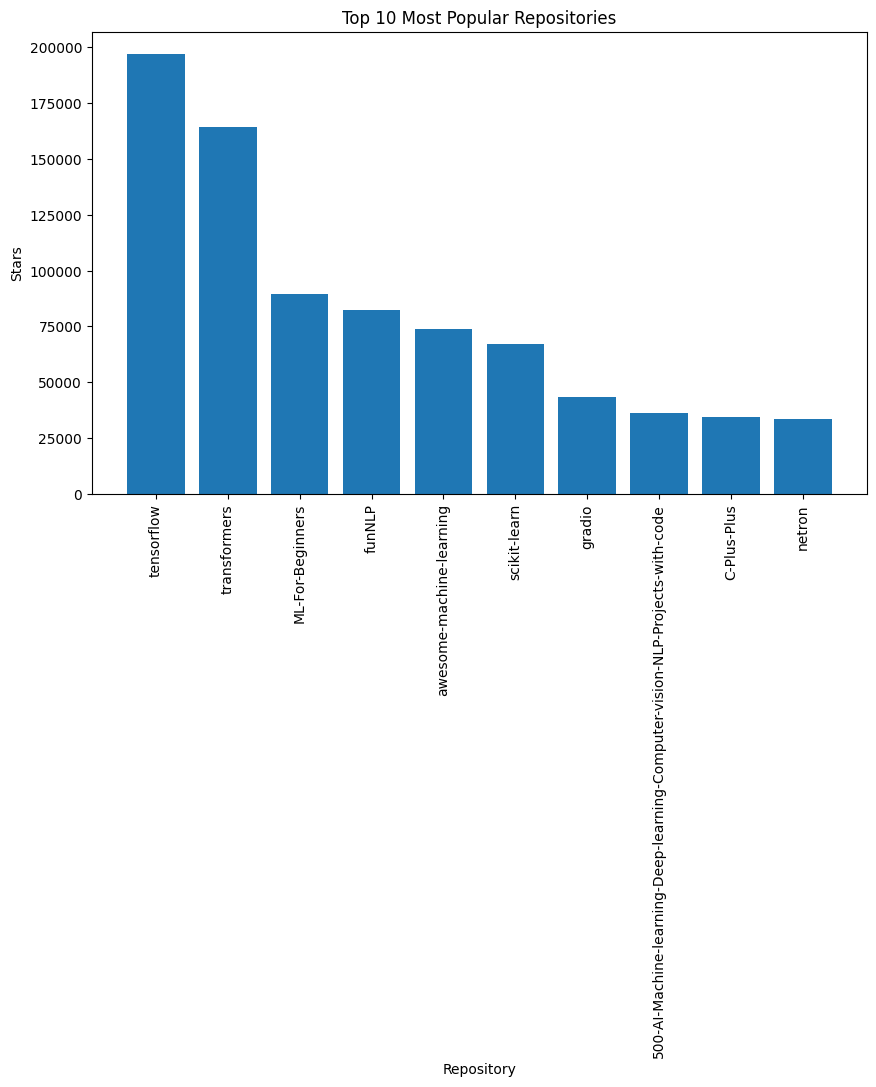

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(top10["name"], top10["stars"])

plt.xticks(rotation=90)
plt.xlabel("Repository")
plt.ylabel("Stars")
plt.title("Top 10 Most Popular Repositories")

plt.show()

In [ ]:
df["created_date"] = pd.to_datetime(df["created_date"])

creation_trends = df.groupby(
    df["created_date"].dt.year
).size()

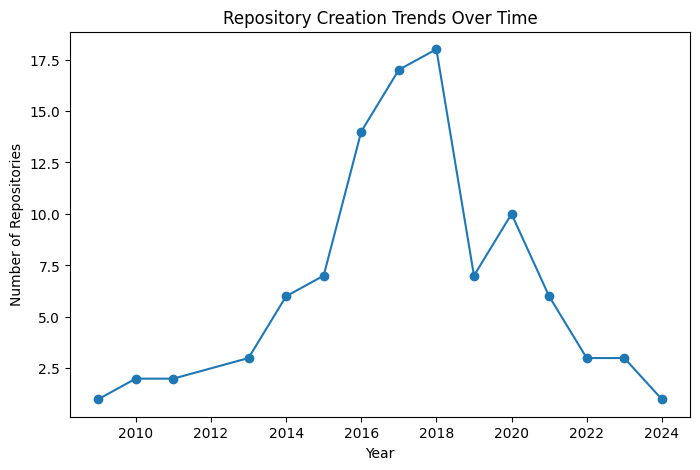

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(creation_trends.index, creation_trends.values, marker="o")

plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.title("Repository Creation Trends Over Time")

plt.show()

## Interpretation & Insights

- The analysis identified the repositories with the highest number of stars.
- The Top 10 repositories represent the most popular repositories in the collected dataset.
- The filtering queries identified repositories with more than 10,000 stars and repositories containing "Machine" in their names.
- The programming language analysis showed which languages had more than 5 repositories.
- The creation trend visualization shows how the repositories in the dataset were created over time.

## Ethics Reflection

### 1. Why is it important to verify data collected from public APIs?

It is important to verify public API data because it may contain missing, incorrect, or outdated information. Checking the data helps ensure that the analysis is based on reliable information.

### 2. Why should data analysts document the source of their data?

Data analysts should document the data source so they can clearly explain where the data came from. This makes the analysis more transparent and easier to verify.

### 3. How can missing or inaccurate data affect data analysis and decision-making?

Missing or inaccurate data can lead to incorrect results and misleading conclusions. This may cause the business to make poor decisions, so the data should be checked and cleaned before analysis.